# Exploring global wheat yields with FAOSTAT data

In this project we investigate how wheat yields have evolved across countries using FAOSTAT data from 1961–2023.  
We focus on three main questions:

1. **How have wheat yields changed across countries from 1961–2023?**  
   Which countries have the highest yields and the fastest improvements?

2. **Can we group countries into clusters with similar yield dynamics**  
   (e.g. average level, variability, long-term trend)? What characterises these clusters?

3. **Can we use information from “similar” countries to improve yield predictions?**  
   In other words, can cross-country information beat simple national baselines?

The rest of this notebook is organised as follows:
- Section 1: Data loading and initial exploration  
- Section 2: Cleaning and transforming the FAOSTAT data  
- Section 3: Exploratory analysis to answer Question 1  
- Section 4: Clustering countries Question 2
- Section 5: Predictive models and evaluation Question 3

## 1. Data loading and first look at FAOSTAT wheat data

We start by loading the FAOSTAT data file that contains information on agricultural production for many countries and years.  
Our aim in this section is to:

- Confirm the structure of the raw dataset (rows, columns, key fields).
- Understand how years are encoded (e.g. `Y1961`, `Y1962`, …).
- Check which variables we will need for yield analysis.

This will help us plan the cleaning steps and ensure we are actually working with *yield* rather than production or area harvested.

In [331]:
# Library import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [332]:
# Load dataset 
df = pd.read_csv('data/Production_Crops_Livestock_E_All_Data.csv')

/var/folders/6z/5ds6pqr14hq4rzt701_p13lr0000gn/T/ipykernel_36336/3128525061.py:2: DtypeWarning: Columns (11,14,17,20,23,26,29,32,35,38,41,44,47,50,53,56,59,62,65,68,71,74,77,80,83,86,89,92,95,98,101,104,107,110,113,116,119,122,125,128,131,134,137,140,143,146,149,152,155,158,161,164,167,170,173,176,179,182,185,188,191,194,197) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/Production_Crops_Livestock_E_All_Data.csv')


In [333]:
# Display first few rows
df.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2020N,Y2021,Y2021F,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N
0,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5312,Area harvested,ha,0.0,...,NaN,36862.0,A,NaN,36462.0,A,NaN,37000.0,A,NaN
1,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5412,Yield,kg/ha,NaN,...,NaN,1743.2,A,NaN,1742.0,A,NaN,1810.8,A,NaN
2,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5510,Production,t,0.0,...,NaN,64256.0,A,NaN,63515.0,A,NaN,67000.0,A,NaN
3,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5312,Area harvested,ha,NaN,...,NaN,25357.0,E,NaN,25403.0,E,NaN,25439.0,E,NaN
4,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5412,Yield,kg/ha,NaN,...,NaN,705.0,E,NaN,704.0,E,NaN,704.0,E,NaN


In [334]:
# Check dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79711 entries, 0 to 79710
Columns: 198 entries, Area Code to Y2023N
dtypes: float64(63), int64(3), object(132)
memory usage: 120.4+ MB


In [335]:
# View summary statistics
df.describe()

,Area Code,Item Code,Element Code,Y1961,Y1962,Y1963,Y1964,Y1965,Y1966,Y1967,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
count,79711.000000,79711.000000,79711.000000,5.737000e+04,5.737700e+04,5.737600e+04,5.739100e+04,5.738600e+04,5.744700e+04,5.745100e+04,...,7.103000e+04,7.109600e+04,7.118300e+04,7.141000e+04,7.072900e+04,7.082200e+04,7.093500e+04,7.099100e+04,7.112000e+04,6.614500e+04
mean,1313.302568,865.879251,5408.833310,1.514965e+06,1.549240e+06,1.582932e+06,1.630178e+06,1.663916e+06,1.704733e+06,1.749159e+06,...,3.156620e+06,3.184441e+06,3.226641e+06,3.273442e+06,3.329584e+06,3.345364e+06,3.384600e+06,3.464475e+06,3.504832e+06,3.752891e+06
std,2194.895639,1461.515725,101.505636,1.586835e+07,1.615213e+07,1.645200e+07,1.694783e+07,1.731071e+07,1.775626e+07,1.817071e+07,...,3.576517e+07,3.611638e+07,3.656186e+07,3.692842e+07,3.735102e+07,3.722087e+07,3.759316e+07,3.870242e+07,3.929182e+07,4.156594e+07
min,1.000000,15.000000,5111.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,89.000000,358.000000,5312.000000,8.362500e+02,8.625000e+02,8.929750e+02,9.100000e+02,9.343750e+02,9.500000e+02,9.885000e+02,...,1.524205e+03,1.543307e+03,1.560000e+03,1.557030e+03,1.442300e+03,1.433050e+03,1.432300e+03,1.437730e+03,1.441750e+03,1.389000e+03
50%,169.000000,587.000000,5412.000000,7.500000e+03,7.700000e+03,7.981640e+03,8.000000e+03,8.130950e+03,8.400000e+03,8.647000e+03,...,1.207270e+04,1.223683e+04,1.234740e+04,1.237300e+04,1.222000e+04,1.225000e+04,1.218570e+04,1.214760e+04,1.220000e+04,1.174500e+04
75%,272.000000,1037.000000,5510.000000,6.655310e+04,6.874600e+04,7.060525e+04,7.305150e+04,7.500000e+04,7.721212e+04,7.975700e+04,...,1.211520e+05,1.225511e+05,1.234405e+05,1.241075e+05,1.255072e+05,1.269745e+05,1.263125e+05,1.270417e+05,1.278680e+05,1.227800e+05
max,5817.000000,17530.000000,5513.000000,1.342210e+09,1.360092e+09,1.368767e+09,1.381032e+09,1.397533e+09,1.408673e+09,1.428836e+09,...,2.818170e+09,2.837867e+09,2.912244e+09,2.961412e+09,2.901857e+09,2.964207e+09,3.008965e+09,3.070651e+09,3.073689e+09,3.134294e+09


### Observations from the raw data
- 79711 rows, 198 columns 
- Years are given as separate columns from `Y1961` to `Y2023`.  
- The `Element` column includes several metrics (e.g. production, area harvested, yield) — for our analysis we only keep **wheat yield**.  
- Some countries have missing values in certain years, which we will handle in the cleaning step.
- Contains some information of regions e.g. Europe, Africa, etc.


## 2. Data cleaning and preprocessing

FAOSTAT provides a rich but fairly messy dataset.  
In this section we:

1. **Filter to wheat yield observations only**, removing other elements (e.g. production, area harvested).  
2. **Drop metadata columns** (flags, notes) that are not needed for the analysis.  
3. **Handle missing data** by:
   - keeping only countries with at least **80% of years observed**, and  
   - interpolating the remaining gaps over time within each country.  

The goal is to end up with a clean `country × year` table of wheat yields suitable for time series analysis, clustering, and prediction.


In [336]:
# Standardise column names
# Start with country names
# Remove quotes and extra spaces for consistency
df['Area'] = df['Area'].str.replace("'", "").str.strip()

# Clean crop names by removing extra spaces 
df['Item'] = df['Item'].str.strip()

df[['Area', 'Item']].head()

,Area,Item
0,Afghanistan,"Almonds, in shell"
1,Afghanistan,"Almonds, in shell"
2,Afghanistan,"Almonds, in shell"
3,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn..."
4,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn..."


In [337]:
# Filter to Wheat data only

# Create a dataframe for wheat production only
wheat_df = df[df['Item'] == 'Wheat']

# Check first few rows
wheat_df.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2020N,Y2021,Y2021F,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N
196,2,'004,Afghanistan,15,'0111,Wheat,5312,Area harvested,ha,2230000.0,...,NaN,2046564.0,A,NaN,1859339.0,A,NaN,2003070.0,I,NaN
197,2,'004,Afghanistan,15,'0111,Wheat,5412,Yield,kg/ha,1022.0,...,NaN,1963.1,A,NaN,2045.3,A,NaN,2146.7,E,NaN
198,2,'004,Afghanistan,15,'0111,Wheat,5510,Production,t,2279000.0,...,NaN,4017657.0,A,NaN,3802895.0,A,NaN,4300000.0,X,Unofficial figure
539,3,'008,Albania,15,'0111,Wheat,5312,Area harvested,ha,126500.0,...,NaN,54514.0,A,NaN,54267.0,A,NaN,57620.0,A,NaN
540,3,'008,Albania,15,'0111,Wheat,5412,Yield,kg/ha,773.1,...,NaN,4130.5,A,NaN,4296.3,A,NaN,4053.9,A,NaN


In [338]:
# Filter for rows where the element is yield 
wheat_df = wheat_df[wheat_df['Element'] == 'Yield']

wheat_df.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2020N,Y2021,Y2021F,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N
197,2,'004,Afghanistan,15,'0111,Wheat,5412,Yield,kg/ha,1022.0,...,NaN,1963.1,A,NaN,2045.3,A,NaN,2146.7,E,NaN
540,3,'008,Albania,15,'0111,Wheat,5412,Yield,kg/ha,773.1,...,NaN,4130.5,A,NaN,4296.3,A,NaN,4053.9,A,NaN
889,4,'012,Algeria,15,'0111,Wheat,5412,Yield,kg/ha,406.0,...,NaN,1584.3,A,NaN,1666.7,X,NaN,1388.9,X,NaN
1125,7,'024,Angola,15,'0111,Wheat,5412,Yield,kg/ha,1111.1,...,NaN,931.0,E,NaN,931.0,E,NaN,931.0,E,NaN
1720,9,'032,Argentina,15,'0111,Wheat,5412,Yield,kg/ha,1295.0,...,NaN,2759.5,A,NaN,3382.5,A,NaN,2287.6,A,NaN


In [339]:
# Investigate column structure for columns
wheat_df.columns


Index(['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (CPC)',
       'Item', 'Element Code', 'Element', 'Unit', 'Y1961',
       ...
       'Y2020N', 'Y2021', 'Y2021F', 'Y2021N', 'Y2022', 'Y2022F', 'Y2022N',
       'Y2023', 'Y2023F', 'Y2023N'],
      dtype='object', length=198)

In [340]:
# Count year-related columns
# This includes data columns, flags (F), and notes (N) for years 1961-2023")
year_cols = [col for col in df.columns if col.startswith("Y")]
print(f"Total year-related columns: {len(year_cols)}")

Total year-related columns: 189


In [341]:
# Missing values 
# Check missing values
print("Missing values per column:")
wheat_df.isnull().sum()

Missing values per column:


Area Code            0
Area Code (M49)      0
Area                 0
Item Code            0
Item Code (CPC)      0
                  ... 
Y2022F              10
Y2022N             164
Y2023               10
Y2023F              10
Y2023N             164
Length: 198, dtype: int64

In [342]:
# Drop duplicate rows if any 
wheat_df = wheat_df.drop_duplicates()
wheat_df.shape

(164, 198)

In [343]:
# remove flag and note columns
wheat_df = wheat_df.drop(columns=[col for col in wheat_df.columns if col.endswith('F') or col.endswith('N')])
wheat_df.shape

(164, 72)

In [344]:
# redo year_columns after dropping flag and note columns
year_cols = [col for col in wheat_df.columns if col.startswith("Y")]

In [345]:
# remove apostrophes from columns
wheat_df['Area Code (M49)'] = wheat_df['Area Code (M49)'].str.replace("'" , "")
wheat_df['Item Code (CPC)'] = wheat_df['Item Code (CPC)'].str.replace("'" , "")

In [346]:
# Drop unnecessary columns - left with only Area and year data
cols_to_drop = ['Element', 'Item', 'Unit', 'Item Code (CPC)', 'Element Code','Area Code (M49)','Item Code']
wheat_df = wheat_df.drop(columns=cols_to_drop)
wheat_df

,Area Code,Area,Y1961,Y1962,Y1963,Y1964,Y1965,Y1966,Y1967,Y1968,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
197,2,Afghanistan,1022.0,973.5,831.7,951.0,972.3,866.6,1123.2,1156.2,...,2023.7,2195.9,1980.3,2034.2,2210.0,2095.1,1943.4,1963.1,2045.3,2146.7
540,3,Albania,773.1,1052.2,712.7,962.5,1134.4,1239.8,1355.0,1412.4,...,4000.1,3951.1,3900.0,4036.7,3692.7,4068.0,4327.1,4130.5,4296.3,4053.9
889,4,Algeria,406.0,804.5,832.6,531.7,605.7,425.2,633.3,689.9,...,1475.3,1464.0,1183.3,1150.1,2043.3,1963.0,1681.1,1584.3,1666.7,1388.9
1125,7,Angola,1111.1,1111.1,1111.1,928.6,1111.1,1100.0,1350.0,1350.0,...,977.9,962.2,946.6,931.0,915.3,879.8,652.0,931.0,931.0,931.0
1720,9,Argentina,1295.0,1522.2,1575.1,1835.3,1321.2,1198.2,1259.5,983.3,...,2661.9,2810.0,2862.3,3304.7,3180.6,3216.0,2938.7,2759.5,3382.5,2287.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77152,5801,Least Developed Countries,935.1,907.4,815.0,891.1,901.3,843.9,982.9,998.5,...,2291.8,2520.8,2304.2,2424.5,2524.9,2523.2,2473.3,2577.7,2588.3,2615.3
77806,5802,Land Locked Developing Countries,948.9,957.4,836.4,939.7,953.8,852.4,1075.9,1047.9,...,1770.8,1888.8,1874.3,1861.9,1853.8,1851.4,1889.1,1748.6,1922.4,1777.3
78299,5803,Small Island Developing States,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,3000.0,2687.5,...,NaN,702.2,654.3,601.7,522.4,592.8,509.4,561.8,550.3,537.7
78958,5815,Low Income Food Deficit Countries,835.3,917.9,802.8,855.0,901.5,818.8,967.6,954.9,...,2525.6,2851.4,2581.9,2579.8,2575.3,2794.7,2725.7,2617.8,2754.1,2921.3


### 2.1 Handling missing values

The raw data includes countries with many missing years, which can distort both clustering and prediction.

- If we simply drop all rows with any missing values, we would lose a large number of countries.
- Instead, we **filter out only those countries that have less than 80% of their yield data available.**
- For the remaining countries, we **interpolate** missing values along the time axis. Since yields typically evolve smoothly over time (rather than jumping randomly), linear interpolation is a reasonable approximation.

Below we implement this strategy and save the cleaned dataset.


In [347]:
# Filter to only keep countries with at least 80% data completeness
required_non_nan = int(0.8 * len(year_cols))

mask = wheat_df[year_cols].notna().sum(axis=1) >= required_non_nan
wheat_df_filtered = wheat_df[mask].copy()

wheat_df_filtered

,Area Code,Area,Y1961,Y1962,Y1963,Y1964,Y1965,Y1966,Y1967,Y1968,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
197,2,Afghanistan,1022.0,973.5,831.7,951.0,972.3,866.6,1123.2,1156.2,...,2023.7,2195.9,1980.3,2034.2,2210.0,2095.1,1943.4,1963.1,2045.3,2146.7
540,3,Albania,773.1,1052.2,712.7,962.5,1134.4,1239.8,1355.0,1412.4,...,4000.1,3951.1,3900.0,4036.7,3692.7,4068.0,4327.1,4130.5,4296.3,4053.9
889,4,Algeria,406.0,804.5,832.6,531.7,605.7,425.2,633.3,689.9,...,1475.3,1464.0,1183.3,1150.1,2043.3,1963.0,1681.1,1584.3,1666.7,1388.9
1125,7,Angola,1111.1,1111.1,1111.1,928.6,1111.1,1100.0,1350.0,1350.0,...,977.9,962.2,946.6,931.0,915.3,879.8,652.0,931.0,931.0,931.0
1720,9,Argentina,1295.0,1522.2,1575.1,1835.3,1321.2,1198.2,1259.5,983.3,...,2661.9,2810.0,2862.3,3304.7,3180.6,3216.0,2938.7,2759.5,3382.5,2287.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77152,5801,Least Developed Countries,935.1,907.4,815.0,891.1,901.3,843.9,982.9,998.5,...,2291.8,2520.8,2304.2,2424.5,2524.9,2523.2,2473.3,2577.7,2588.3,2615.3
77806,5802,Land Locked Developing Countries,948.9,957.4,836.4,939.7,953.8,852.4,1075.9,1047.9,...,1770.8,1888.8,1874.3,1861.9,1853.8,1851.4,1889.1,1748.6,1922.4,1777.3
78299,5803,Small Island Developing States,2500.0,2500.0,2500.0,2500.0,2500.0,2500.0,3000.0,2687.5,...,NaN,702.2,654.3,601.7,522.4,592.8,509.4,561.8,550.3,537.7
78958,5815,Low Income Food Deficit Countries,835.3,917.9,802.8,855.0,901.5,818.8,967.6,954.9,...,2525.6,2851.4,2581.9,2579.8,2575.3,2794.7,2725.7,2617.8,2754.1,2921.3


In [348]:
# Make a list of countries left over after filtering with their missing data stats

missing_summary = (
    wheat_df_filtered
    .assign(
        missing_count = wheat_df_filtered[year_cols].isna().sum(axis=1),
        total_years   = len(year_cols),
        missing_pct   = wheat_df_filtered[year_cols].isna().mean(axis=1) * 100
    )[
        ["Area Code", "Area", "missing_count", "missing_pct"]
    ]
    .sort_values("missing_pct", ascending=False))

missing_summary.head(10)

,Area Code,Area,missing_count,missing_pct
52476,206,Sudan (former),12,19.047619
44615,179,Qatar,11,17.460317
6729,20,Botswana,9,14.285714
18918,209,Eswatini,9,14.285714
78299,5803,Small Island Developing States,9,14.285714
38894,153,New Caledonia,9,14.285714
75551,5502,Melanesia,9,14.285714
50444,201,Somalia,9,14.285714
35023,134,Malta,6,9.523810
56774,226,Uganda,5,7.936508


In [349]:
# Interpolate missing data
wheat_df_filtered[year_cols] = (
    wheat_df_filtered[year_cols]
    .interpolate(axis=1, limit_direction='both')
)

# Verify interpolation for example country botswana

wheat_df_filtered.loc[6729].isna().sum()

np.int64(0)

In [350]:
# Save the cleaned and interpolated data to a new CSV file

# commented out to avoid overwriting existing file
# wheat_df_filtered.to_csv("extracleaned_wheat_data.csv", index=False)

## 3. Exploratory analysis (Question 1)

> **Question 1:** How have wheat yields changed across countries from 1961–2023?  
> Which countries have the highest yields and the fastest improvements?

From now on we work with the cleaned `country × year` table.  
In this section we:

- Compare the **average yield level** across countries.  
- Look at **long-run changes** in yield (percentage change from 1961 to 2023).  
- Measure **volatility** in yields over time (e.g. using coefficient of variation).  
- Visualise the evolution of yields across time and countries (heatmaps and line plots).


In [351]:
# Reload cleaned data
wheat_df = pd.read_csv('data/extracleaned_wheat_data.csv')

In [352]:
wheat_df.head()

,Area Code,Area,Y1961,Y1962,Y1963,Y1964,Y1965,Y1966,Y1967,Y1968,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
0,2,Afghanistan,1022.0,973.5,831.7,951.0,972.3,866.6,1123.2,1156.2,...,2023.7,2195.9,1980.3,2034.2,2210.0,2095.1,1943.4,1963.1,2045.3,2146.7
1,3,Albania,773.1,1052.2,712.7,962.5,1134.4,1239.8,1355.0,1412.4,...,4000.1,3951.1,3900.0,4036.7,3692.7,4068.0,4327.1,4130.5,4296.3,4053.9
2,4,Algeria,406.0,804.5,832.6,531.7,605.7,425.2,633.3,689.9,...,1475.3,1464.0,1183.3,1150.1,2043.3,1963.0,1681.1,1584.3,1666.7,1388.9
3,7,Angola,1111.1,1111.1,1111.1,928.6,1111.1,1100.0,1350.0,1350.0,...,977.9,962.2,946.6,931.0,915.3,879.8,652.0,931.0,931.0,931.0
4,9,Argentina,1295.0,1522.2,1575.1,1835.3,1321.2,1198.2,1259.5,983.3,...,2661.9,2810.0,2862.3,3304.7,3180.6,3216.0,2938.7,2759.5,3382.5,2287.6


In [353]:
# Set 'Area' as the index

wheat_df.set_index('Area', inplace=True)

In [354]:
# Make a list of year columns 

year_cols = [col for col in wheat_df.columns if col.startswith('Y')]

In [355]:
# Create numeric dataframe
df_numeric = wheat_df[year_cols].copy()

df_numeric.head()

,Y1961,Y1962,Y1963,Y1964,Y1965,Y1966,Y1967,Y1968,Y1969,Y1970,...,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023
Area,,,,,,,,,,,,,,,,,,,,,
Afghanistan,1022.0,973.5,831.7,951.0,972.3,866.6,1123.2,1156.2,1185.5,956.3,...,2023.7,2195.9,1980.3,2034.2,2210.0,2095.1,1943.4,1963.1,2045.3,2146.7
Albania,773.1,1052.2,712.7,962.5,1134.4,1239.8,1355.0,1412.4,1638.9,1537.7,...,4000.1,3951.1,3900.0,4036.7,3692.7,4068.0,4327.1,4130.5,4296.3,4053.9
Algeria,406.0,804.5,832.6,531.7,605.7,425.2,633.3,689.9,603.4,624.5,...,1475.3,1464.0,1183.3,1150.1,2043.3,1963.0,1681.1,1584.3,1666.7,1388.9
Angola,1111.1,1111.1,1111.1,928.6,1111.1,1100.0,1350.0,1350.0,943.0,854.6,...,977.9,962.2,946.6,931.0,915.3,879.8,652.0,931.0,931.0,931.0
Argentina,1295.0,1522.2,1575.1,1835.3,1321.2,1198.2,1259.5,983.3,1352.3,1329.4,...,2661.9,2810.0,2862.3,3304.7,3180.6,3216.0,2938.7,2759.5,3382.5,2287.6


In [356]:
df_numeric.shape

(123, 63)

In [357]:
# Define regions for inital analysis

selection = [
    'Europe',
    'Least Developed Countries',
    'World',
    'Asia',
    'Africa',
    'North America',
    'South America',
    'Oceania'
]

In [358]:
df_manual_selection = df_numeric.loc[df_numeric.index.isin(selection)]

In [359]:
# Transpose for easier plotting

df_transposed = df_manual_selection.transpose()

In [360]:
df_transposed.head()

Area,World,Africa,South America,Asia,Europe,Oceania,Least Developed Countries
Y1961,1088.9,693.0,1135.8,748.6,1256.2,1156.9,935.1
Y1962,1206.0,923.6,1345.3,844.8,1326.9,1270.9,907.4
Y1963,1132.0,899.0,1379.1,853.2,1099.7,1357.5,815.0
Y1964,1241.3,873.6,1636.1,843.1,1351.8,1405.9,891.1
Y1965,1215.1,828.7,1244.6,975.5,1246.9,1021.6,901.3


In [361]:
# Remove 'Y' from year labels and convert to integers

df_transposed.index = df_transposed.index.str.replace('Y', '').astype(int)

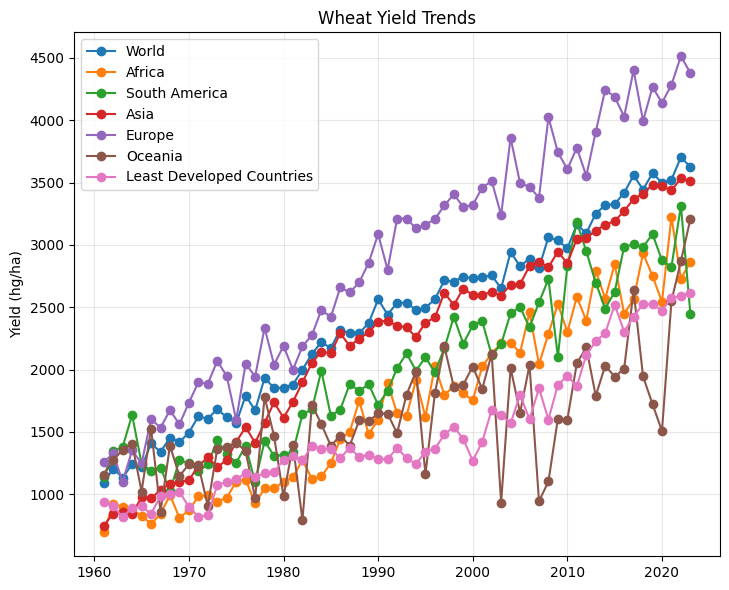

In [362]:
# Calculate correlation matrix
corr_matrix = df_transposed.corr()

plt.figure(figsize=(14, 6))

# Line Plot
plt.subplot(1, 2, 1)
for country in df_transposed.columns:
    plt.plot(df_transposed.index, df_transposed[country], marker='o', label=country)
plt.title('Wheat Yield Trends')
plt.ylabel('Yield (hg/ha)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [363]:
# Filter out aggregate regions by Area Code
wheat_df_countries = wheat_df[wheat_df["Area Code"] < 5000]
wheat_df_countries.drop(columns=["Area Code"], inplace=True)
wheat_df_countries.shape

/var/folders/6z/5ds6pqr14hq4rzt701_p13lr0000gn/T/ipykernel_36336/79877871.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wheat_df_countries.drop(columns=["Area Code"], inplace=True)


(93, 63)

### 3.1 Which countries have the highest average wheat yields?

First, we compute the **mean yield over 1961–2023** for each country and rank them.  
This gives us a sense of which countries are historically high-yield versus low-yield wheat producers.


In [364]:
# Calculate mean yield for each country and sort descending
country_mean = wheat_df_countries.mean(axis=1).sort_values(ascending=False)

# Display top 10 countries by mean yield
country_mean.head(10)

Area
Netherlands (Kingdom of the)                            7164.376190
Ireland                                                 7017.280952
United Kingdom of Great Britain and Northern Ireland    6502.884127
Denmark                                                 6308.947619
Germany                                                 6021.860317
France                                                  5760.352381
New Zealand                                             5687.298413
Sweden                                                  5296.693651
Switzerland                                             5108.692063
Egypt                                                   4847.693651
dtype: float64

In [365]:
# Display bottom 10 countries by mean yield
country_mean.tail(10)

Area
Algeria                             1003.190476
Mongolia                             971.558730
Ecuador                              937.144444
Bolivia (Plurinational State of)     913.515873
Rwanda                               892.684127
Lesotho                              777.109524
Burundi                              719.479365
Libya                                652.698413
Honduras                             650.176190
Somalia                              235.792063
dtype: float64

In [366]:
# Calculate percentage change in yield from 1961 to 2023 for each country
pct_change = ((wheat_df_countries['Y2023'] - wheat_df_countries['Y1961']) / wheat_df_countries['Y1961']) * 100
pct_change_sorted = pct_change.sort_values(ascending=False)

# Show top 10 countries by percentage change
pct_change_sorted.head(10)

Area
Somalia                                      inf
China, mainland                       936.410900
China                                 933.947415
Mauritania                            883.798380
South Africa                          515.638126
Bangladesh                            509.027536
Uruguay                               490.953889
Namibia                               488.365258
Albania                               424.369422
Venezuela (Bolivarian Republic of)    410.679252
dtype: float64

In [367]:
# Remove infinite values resulting from division by zero
pct_change_sorted = pct_change_sorted.replace([np.inf, -np.inf], np.nan).dropna()

# Remove china from the list - includes data from taiwan which skews results
pct_change_sorted = pct_change_sorted.drop('China')

# Also drop China from the dataframe to avoid skewing
wheat_df_countries = wheat_df_countries.drop('China')  

### 3.2 Long-run improvements in yield

To understand which countries have improved the most, we compute the **percentage change** in yield between 1961 and 2023 (where both years are available).  

We then plot the top 15 countries by percentage increase. This highlights countries that may have achieved substantial productivity gains, even if their absolute yield level is not the highest.


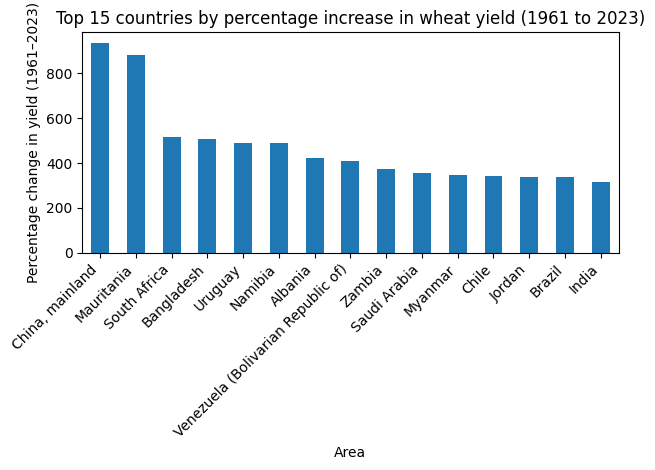

In [368]:
# Visualize top 15 countries by percentage increase in wheat yield

plt.figure()
pct_change_sorted.head(15).plot(kind="bar")
plt.ylabel("Percentage change in yield (1961–2023)")
plt.title(f"Top 15 countries by percentage increase in wheat yield (1961 to 2023)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

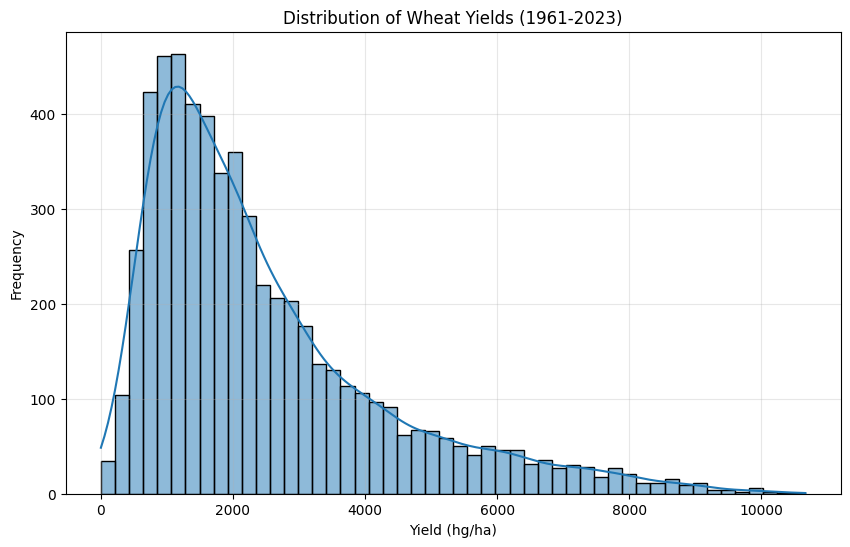

In [369]:
year_cols = [col for col in wheat_df_countries.columns if col.startswith('Y')]

# Get all yield values for histogram
all_yields = wheat_df_countries[year_cols].values.flatten()

# Plot histogram of all yield values to see distribution
plt.figure(figsize=(10, 6))
sns.histplot(all_yields, bins=50, kde=True)
plt.title("Distribution of Wheat Yields (1961-2023)")
plt.xlabel("Yield (hg/ha)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

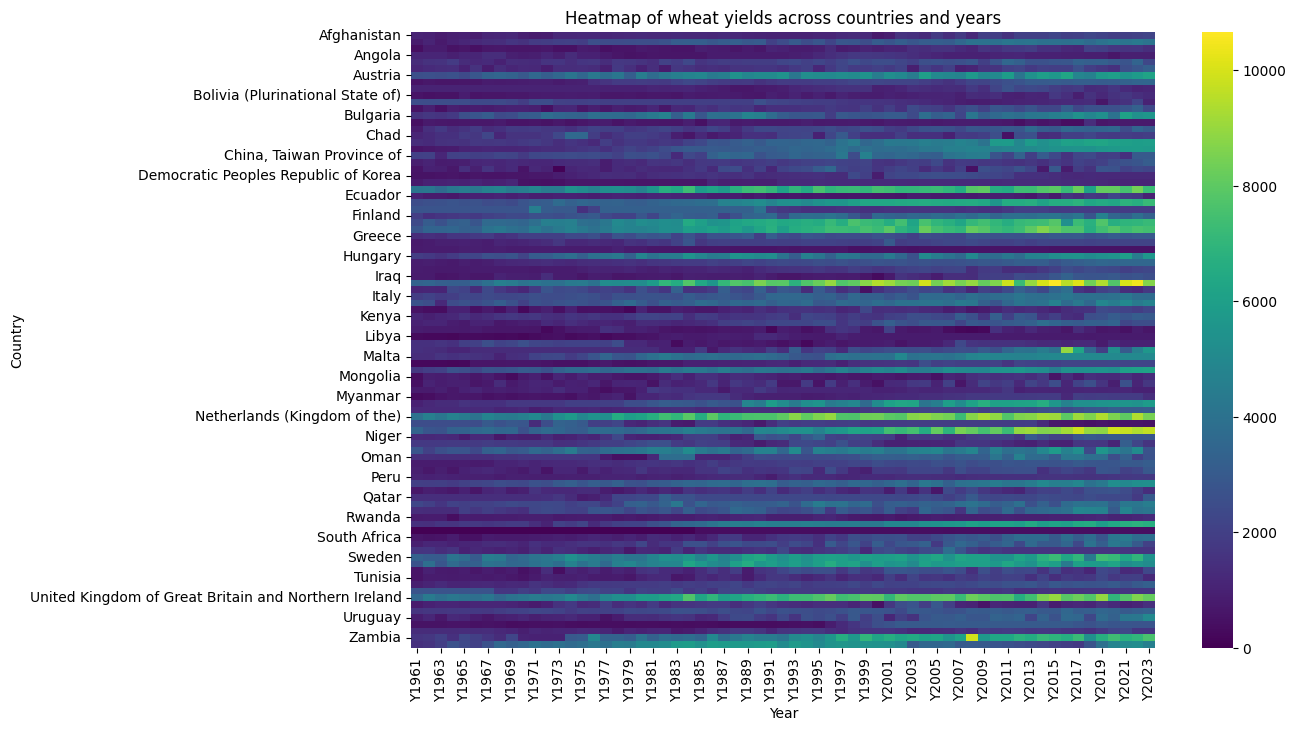

In [370]:
# Heatmap of wheat yields across countries and years
plt.figure(figsize=(12,8))
sns.heatmap(wheat_df_countries[year_cols], cmap="viridis")
plt.title("Heatmap of wheat yields across countries and years")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

### 3.3 Volatility in wheat yields

Stable yields are often as important as high yields.  
We therefore compute a simple measure of volatility (the coefficient of variation: standard deviation / mean) for each country’s yield time series.

Countries with high CV might be more exposed to climate variability, policy changes, or other shocks.


In [371]:
# Find out most volatile countries 
volatility = wheat_df_countries[year_cols].std(axis=1).sort_values(ascending=False)

# Display top 10 most volatile countries
volatility.head(10)

Area
New Zealand                                             2313.592563
Ireland                                                 2273.264969
Zambia                                                  2098.915666
Saudi Arabia                                            1829.637761
Namibia                                                 1819.994816
Netherlands (Kingdom of the)                            1700.842221
Chile                                                   1676.637665
United Kingdom of Great Britain and Northern Ireland    1633.524491
China, mainland                                         1618.049712
Germany                                                 1602.051322
dtype: float64

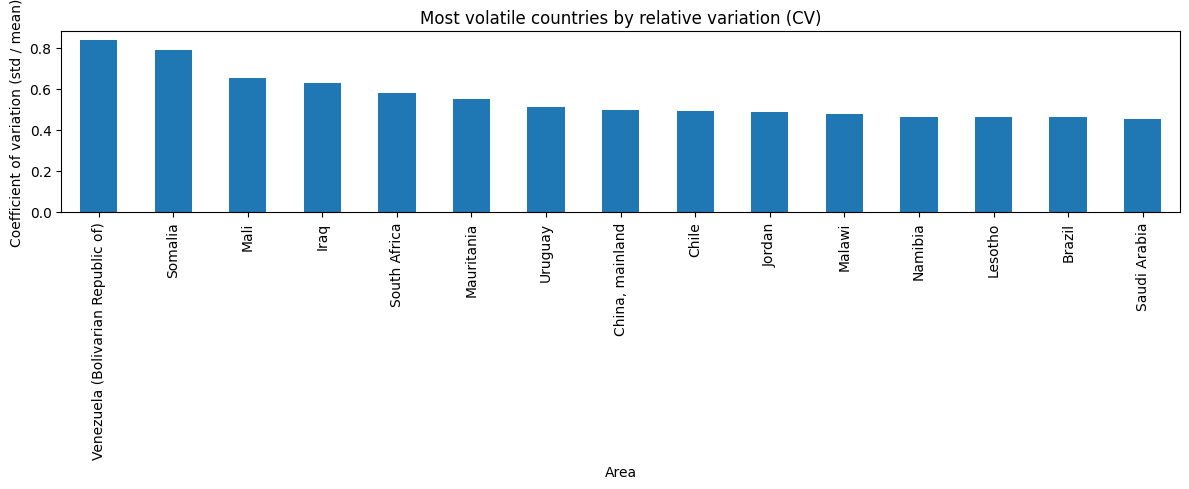

In [372]:
#For Coefficient of Variation (CV) calculation to find countries with high relative volatility
mean_yield = wheat_df_countries[year_cols].mean(axis=1)
std_yield  = wheat_df_countries[year_cols].std(axis=1)

# Coefficient of Variation
cv = (std_yield / mean_yield)  # unitless measure of volatility

cv_sorted = cv.sort_values(ascending=False)

# Visualize top 15 most volatile countries by CV
plt.figure(figsize=(12,5))
cv_sorted.head(15).plot(kind="bar")
plt.title("Most volatile countries by relative variation (CV)")
plt.ylabel("Coefficient of variation (std / mean)")
plt.tight_layout()
plt.show()

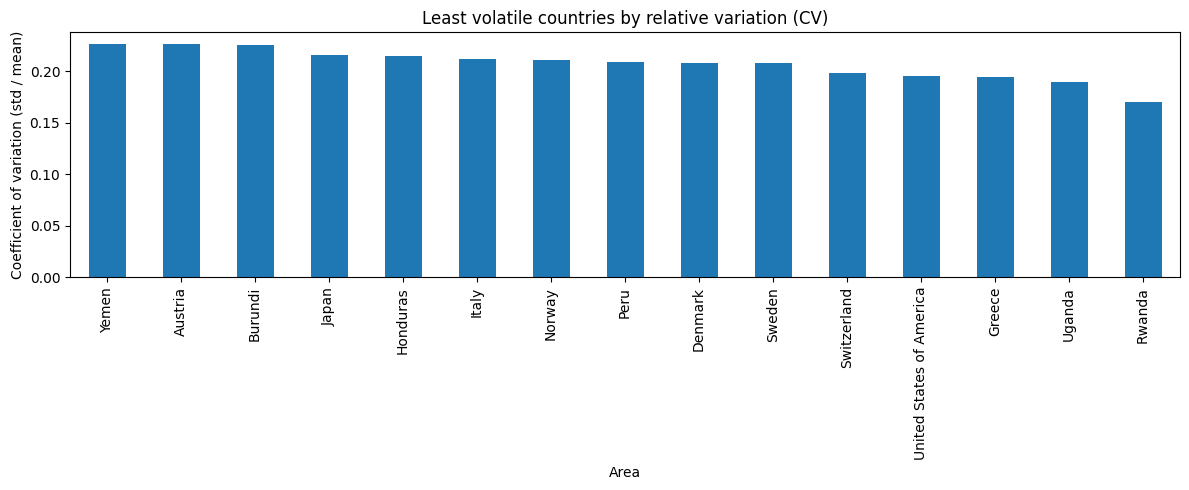

In [373]:
# Visualize top 15 least volatile countries by CV
plt.figure(figsize=(12,5))
cv_sorted.tail(15).plot(kind="bar")
plt.title("Least volatile countries by relative variation (CV)")
plt.ylabel("Coefficient of variation (std / mean)")
plt.tight_layout()
plt.show()

#### Interpretation

- High-income temperate countries (e.g. Netherlands, Ireland, New Zealand) tend to have the highest average yields.  
- Several countries in Africa show relatively low mean yields but high growth rates, suggesting catch-up over this period.  
- China and South Africa stand out as both **high level** and **fast improving**, which may reflect strong investment in agricultural technology and management.


#### Correlation Heatmap

This heatmap helps to visualise which countries follow similar yield trends over the time series.

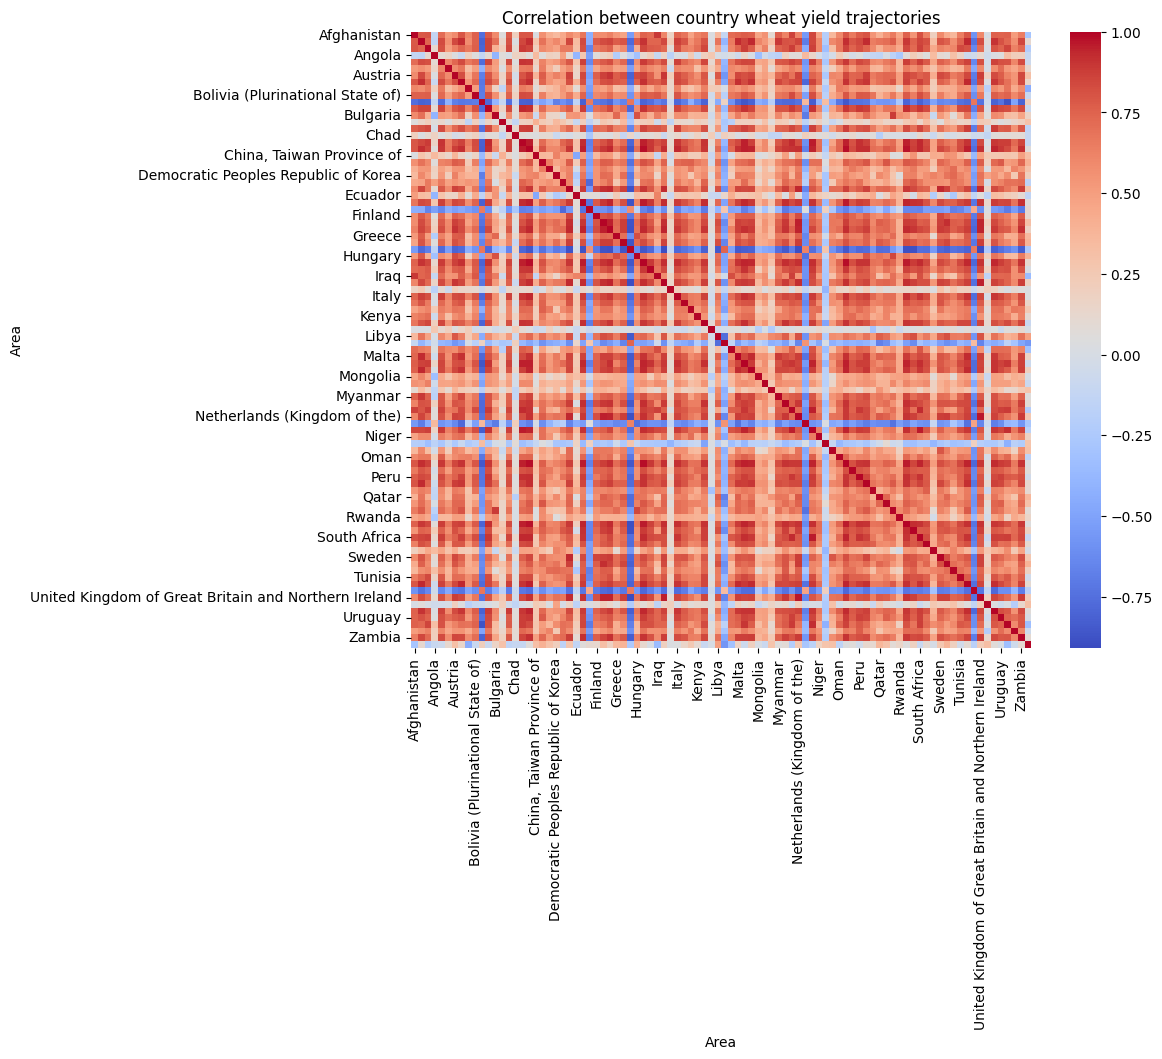

In [374]:
# Correlation heatmap between countries based on yield trajectories

corr = wheat_df_countries[year_cols].T.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation between country wheat yield trajectories")
plt.show()

# Countries with highest correlation will show up near 1 in the heatmap

In [375]:
# Identify pairs of countries with high correlation (>0.8) for potential predictive relationships
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if corr.iloc[i, j] > 0.8:
            high_corr_pairs.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))
# Display high correlation pairs
high_corr_pairs

[('Afghanistan', 'Iraq', np.float64(0.894995565703291)),
 ('Afghanistan', 'Nepal', np.float64(0.8599513246827062)),
 ('Afghanistan', 'New Zealand', np.float64(0.8486212746518711)),
 ('Afghanistan', 'South Africa', np.float64(0.8161978414136178)),
 ('Albania', 'Argentina', np.float64(0.8355616904378338)),
 ('Albania', 'Austria', np.float64(0.8434043902366632)),
 ('Albania', 'Bangladesh', np.float64(0.9182214544733156)),
 ('Albania', 'Brazil', np.float64(0.8517627342230417)),
 ('Albania', 'Canada', np.float64(0.8131183845355232)),
 ('Albania', 'Chile', np.float64(0.8481810244811206)),
 ('Albania', 'China, mainland', np.float64(0.9251884864019995)),
 ('Albania', 'Denmark', np.float64(0.8454640891265417)),
 ('Albania', 'Egypt', np.float64(0.8375016510155391)),
 ('Albania', 'France', np.float64(0.8350293069519644)),
 ('Albania', 'Germany', np.float64(0.85494288072179)),
 ('Albania', 'Guatemala', np.float64(0.8006582458311003)),
 ('Albania', 'India', np.float64(0.9048801554681108)),
 ('Alban

Before attempting cross-country prediction, correlations between yield time series were examined to identify which countries displayed similar temporal patterns. High positive correlations suggest potential predictive relationships at different lags.

In [376]:
#Reshape data to long format for easier analysis
wheat_long = (
    wheat_df_countries[year_cols]
    .reset_index()  # bring 'Area' back as a column
    .melt(id_vars="Area", var_name="Year", value_name="Yield")
)

# Turn "Y1961" -> 1961
wheat_long["Year"] = wheat_long["Year"].str[1:].astype(int)

In [377]:
import statsmodels.api as sm

In [378]:
#Simple linear regression model per country to find yield trends over time
country = "China, mainland"
sub = wheat_long[wheat_long["Area"] == country]

model = sm.formula.ols("Yield ~ Year", data=sub).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Yield   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     5329.
Date:                Mon, 15 Dec 2025   Prob (F-statistic):           4.45e-61
Time:                        16:42:49   Log-Likelihood:                -413.23
No. Observations:                  63   AIC:                             830.5
Df Residuals:                      61   BIC:                             834.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.716e+05   2395.097    -71.644      0.0

## 4. Clustering countries by yield dynamics (Question 2)

> **Question 2:** Can we group countries into clusters with similar yield dynamics (level, variability, trend)? What characterises these clusters?

Instead of looking at each country individually, we want to see whether there are **systematic patterns** in how yields behave over time.

We construct a simple feature set for each country:

- **Average yield** over the full period.  
- **Trend (slope)**: the estimated linear trend in yield over time.  
- **Volatility**: e.g. the standard deviation or coefficient of variation.  

We then standardise these features and apply **k-means clustering** to group countries into a small number of clusters.  
The idea is that each cluster corresponds to a distinct “type” of yield trajectory (e.g. high-stable, low-improving, volatile).


In [379]:
def get_slope(y):
    df = pd.DataFrame({
        'Year': range(1961, 2024),
        'Yield': y
    })
    model = sm.formula.ols("Yield ~ Year", data=df).fit()
    return model.params['Year']  # Return the slope coefficient

slopes = wheat_df_countries[year_cols].apply(get_slope, axis=1)

# Build feature table: one row per country with level, trend, volatility
features = pd.DataFrame({
    'mean_yield': mean_yield,
    'std': std_yield,
    'cv': cv,
    'slope': slopes
})

features.head()


,mean_yield,std,cv,slope
Area,,,,
Afghanistan,1360.733333,417.257002,0.306641,18.354892
Albania,2805.441270,983.435434,0.350546,49.547605
Algeria,1003.190476,440.879786,0.439478,20.823450
Angola,1013.742857,291.167149,0.287220,1.416801
Argentina,2116.706349,627.179294,0.296300,30.786194


In [380]:
from sklearn.preprocessing import StandardScaler

# Standardise features so that k-means is not dominated by the scale of any variable
X_scaled = StandardScaler().fit_transform(features)

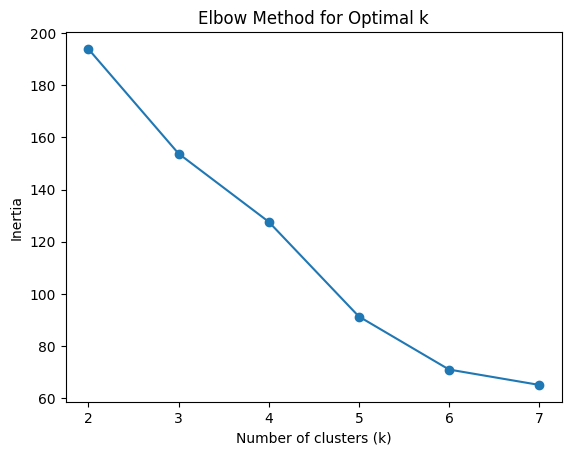

In [381]:
from sklearn.cluster import KMeans

# Attempt at k-means clustering

inertia = []
K_range = range(2, 8)

# Run k-means clustering for different values of k to find optimal number of clusters
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [382]:
# Run k-means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
features["cluster"] = kmeans.fit_predict(X_scaled)
features.head()

,mean_yield,std,cv,slope,cluster
Area,,,,,
Afghanistan,1360.733333,417.257002,0.306641,18.354892,2
Albania,2805.441270,983.435434,0.350546,49.547605,0
Algeria,1003.190476,440.879786,0.439478,20.823450,2
Angola,1013.742857,291.167149,0.287220,1.416801,2
Argentina,2116.706349,627.179294,0.296300,30.786194,0


### 4.1 Interpreting the clusters

After fitting k-means, we examine the average feature values in each cluster and visualise the typical yield trajectory over time.

This helps us interpret clusters in more concrete terms, such as:

- **Cluster 0:**
    - Moderate wheat yields but experience noticeable year-to-year variability.
    - Long-term improvement is positive but modest, suggesting slow technological adoption or inconsistent environmental conditions.
    - May face climate instability, varying rainfall, or dependency on fluctuating input use.
- **Cluster 1:**   
    - High but extremely volatile yields
    - Highest relative variability (CV > 0.5), meaning yields swing widely from year to year.
    - Strongest long-term trend, indicating rapid improvements but from a fluctuating base. 
        - Could reflect policy driven yield boosts.
        - Climate sensitive regions that occaisionally achieve high yields.
- **Cluster 2:**   
    - Consistently low yields but also relatively stable production.
    - Long-term improvement is very slow, indicating limited technological progress or persistent structural constraints.
        - Economies with limited agricultural investment
        - Countries relying on traditional farming systems
        - Regions with climatic or soil constraints
- **Cluster 3:** 
    - Very high yields, maintain stable performance relative to their mean (lowest CV), and show strong positive long-term trends.
    - Global agricultural leaders, likely including countries with:
        - Advanced crop breeding
        - Advanced farming techonlogy
        - Controlled irrigation
        - Consistent and stable agricultural policy

In [383]:
features.groupby("cluster").mean()

,mean_yield,std,cv,slope
cluster,,,,
0,2484.244598,827.009743,0.357001,34.736934
1,3394.565256,1685.070785,0.538418,84.641892
2,1382.532172,435.574620,0.331978,8.292440
3,5704.431890,1442.501119,0.251958,70.669884


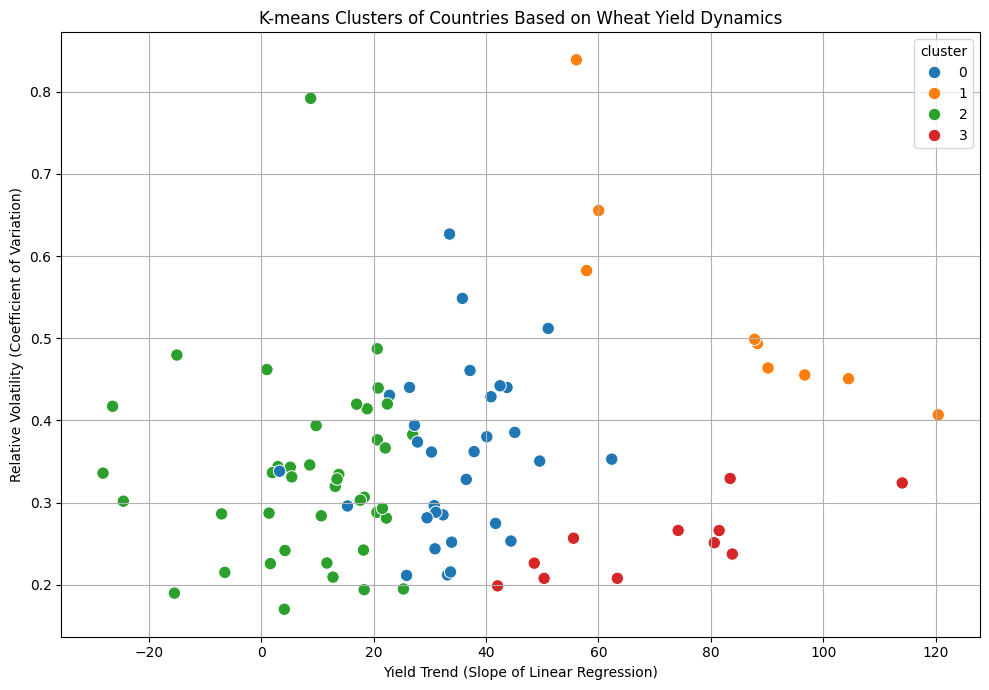

In [384]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=features,
    x="slope",
    y="cv",
    hue="cluster",
    palette="tab10",
    s=80
)

plt.title("K-means Clusters of Countries Based on Wheat Yield Dynamics")
plt.xlabel("Yield Trend (Slope of Linear Regression)")
plt.ylabel("Relative Volatility (Coefficient of Variation)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [385]:
cluster_id = 3
cluster_countries = features[features["cluster"] == cluster_id].index.tolist()
cluster_countries


['Austria',
 'Denmark',
 'Egypt',
 'France',
 'Germany',
 'Ireland',
 'Mexico',
 'Netherlands (Kingdom of the)',
 'Sweden',
 'Switzerland',
 'United Kingdom of Great Britain and Northern Ireland']

In [386]:
cluster_summary = (
    features
    .groupby("cluster")
    .agg(
        n_countries=("mean_yield", "size"),
        mean_yield=("mean_yield", "mean"),
        mean_slope=("slope", "mean"),
        mean_cv=("cv", "mean"),
        mean_std=("std", "mean")
    )
    .sort_values("mean_yield", ascending=False)
)

cluster_summary

,n_countries,mean_yield,mean_slope,mean_cv,mean_std
cluster,,,,,
3,11,5704.431890,70.669884,0.251958,1442.501119
1,9,3394.565256,84.641892,0.538418,1685.070785
0,31,2484.244598,34.736934,0.357001,827.009743
2,41,1382.532172,8.292440,0.331978,435.574620


## 5. Predicting wheat yields (Question 3)

> **Question 3:** Given a country’s past yields and the yields of “similar” countries, can we predict that country’s yields better than simple baselines?

We now focus on **forecasting** wheat yields for a given target country.

We compare several models:

1. **Naive baseline:** next year’s yield is equal to last year’s yield (`y_t = y_{t-1}`).  
2. **Own-history linear regression:** predict yield using only the country’s own past yields and time.  
3. **Cluster-augmented regression:** predict yield using both the country’s own history and the average yield of countries in the *same cluster* (from Section 4).

We train models on an initial part of the time series and evaluate them on a **hold-out test set** of recent years using standard error metrics (e.g. MAE, RMSE).


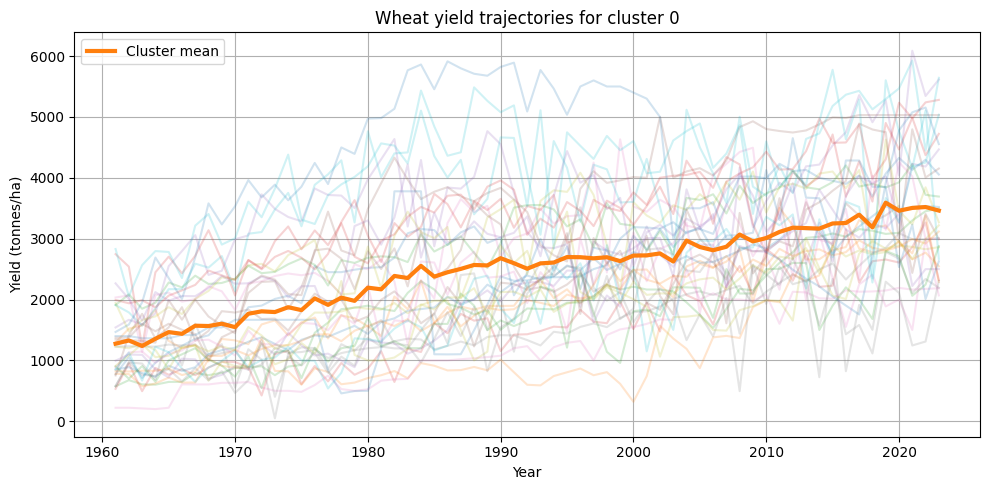

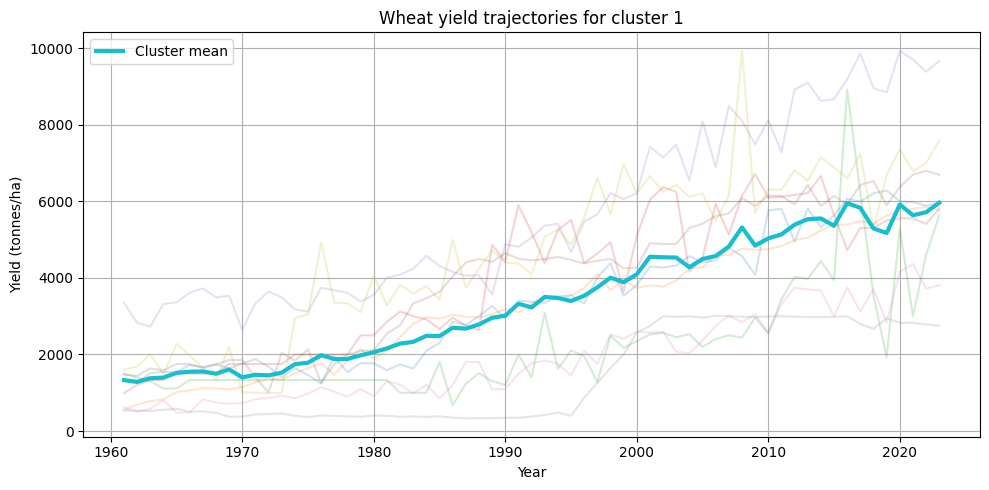

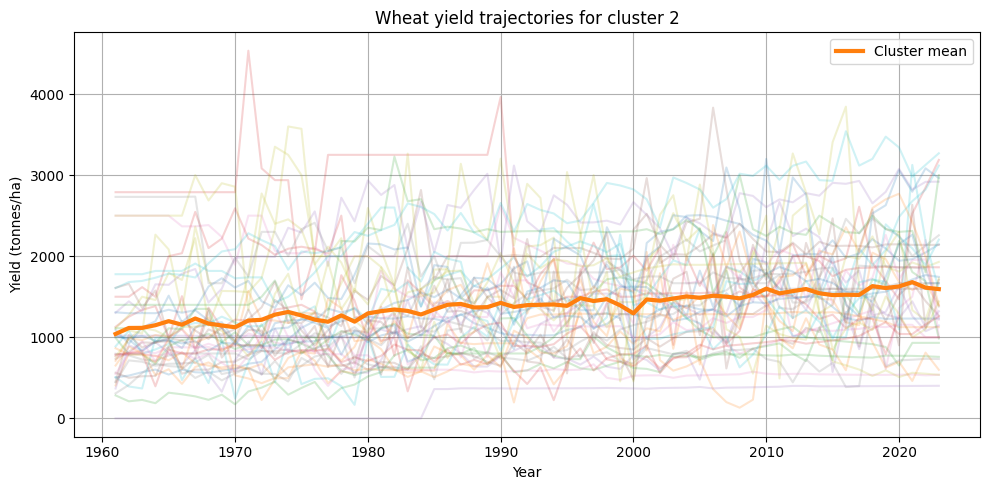

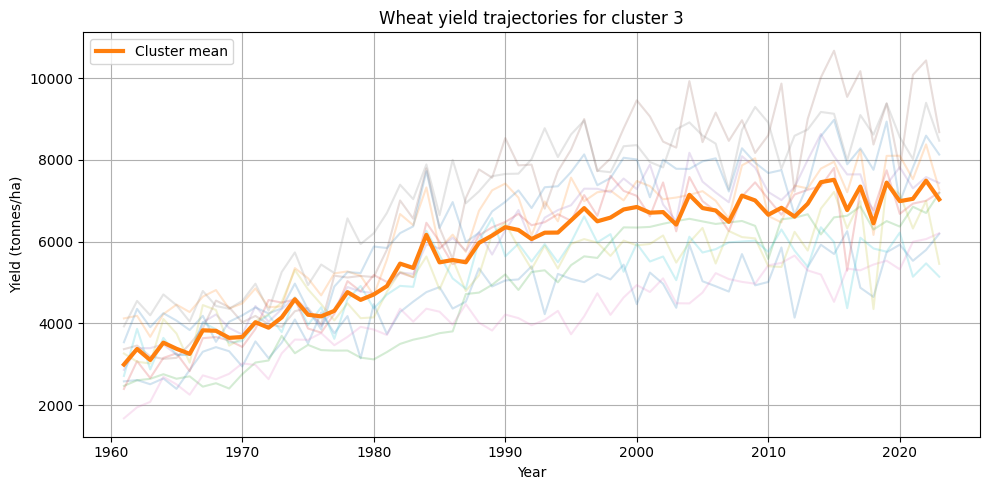

In [387]:
# Visualize yield trajectories for each cluster
years = [int(c[1:]) for c in year_cols] 

for cid in sorted(features["cluster"].unique()):
    plt.figure(figsize=(10, 5))
    
    members = features[features["cluster"] == cid].index
    subset = wheat_df_countries.loc[members, year_cols]
    
    # Plot each country's trajectory faintly
    for country, row in subset.iterrows():
        plt.plot(years, row.values, alpha=0.2)
    
    # Overlay cluster mean trajectory
    plt.plot(years, subset.mean(axis=0).values, linewidth=3, label="Cluster mean")
    
    plt.title(f"Wheat yield trajectories for cluster {cid}")
    plt.xlabel("Year")
    plt.ylabel("Yield (tonnes/ha)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Interpretation
- 4 graphs showing yield changes from 1961 - 2023 with mean cluster yield overlayed.
- Helps to visualise the cluster trends.

### 5.1 Preparing data for modelling

To build time-series models, we reshape the data into a **long format** with columns:

- `Area` (country)  
- `Year`  
- `Yield`

We also merge in cluster assignments from Section 4 so that each observation knows which cluster its country belongs to.


In [388]:
# Reshape wide (one row per country, many year columns) -> long (one row per country-year)
wheat_long = wheat_long.merge(
    features[["cluster"]],
    left_on="Area",
    right_index=True,
    how="left"
)

wheat_long.head()

,Area,Year,Yield,cluster
0,Afghanistan,1961,1022.0,2
1,Albania,1961,773.1,0
2,Algeria,1961,406.0,2
3,Angola,1961,1111.1,2
4,Argentina,1961,1295.0,0


In [389]:
# Saving files to to make data available for app.py
#wheat_long.to_csv("wheat_yield_long_with_clusters.csv", index=False)
#features.to_csv("wheat_yield_country_features_with_clusters.csv")

In [390]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Build a regression dataset for one target country, using:
    #- its own lagged yield (t-1)
    #- the cluster mean yield at t-1 (excluding the target country)

def make_country_dataset(target_country, train_end_year=2000):

    # Get cluster of the target and other members in the same cluster
    cluster_id = features.loc[target_country, "cluster"]
    cluster_members = features[features["cluster"] == cluster_id].index.tolist()
    other_members = [c for c in cluster_members if c != target_country]
    
    # Pivot to Year x Area wide format for all members of this cluster
    df_cluster = wheat_long[wheat_long["Area"].isin(cluster_members)]
    wide = df_cluster.pivot(index="Year", columns="Area", values="Yield").sort_index()
    
    # Target series
    y = wide[target_country]
    
    # Own lag
    X = pd.DataFrame(index=wide.index)
    X["y_lag1"] = y.shift(1)

    # Own lag -2
    X["y_lag2"] = y.shift(2)
    
    # Cluster mean lag (excluding the target)
    X["cluster_mean_lag1"] = wide[other_members].mean(axis=1).shift(1)
    
    # Add time trend
    X["Year"] = X.index
    
    # Combine with target and drop rows with missing lagged data
    data = pd.concat([X, y.rename("y")], axis=1).dropna()
    
    # Train/test split by time
    train_mask = data["Year"] <= train_end_year
    train = data[train_mask]
    test = data[~train_mask]
    
    X_train = train.drop(columns="y")
    y_train = train["y"]
    X_test = test.drop(columns="y")
    y_test = test["y"]
    
    return X_train, X_test, y_train, y_test, data


In [391]:
# Set target country for regression dataset
target_country = "China, mainland" 

# Generate dataset for the target country
X_train, X_test, y_train, y_test, data_all = make_country_dataset(target_country, train_end_year=2000)

print(f"Train period: {int(data_all['Year'].min())}–2000")
print(f"Test period:  {int(data_all[~(data_all['Year'] <= 2000)]['Year'].min())}–{int(data_all['Year'].max())}")
print("Train size:", len(X_train), "Test size:", len(X_test))


Train period: 1963–2000
Test period:  2001–2023
Train size: 38 Test size: 23


### 5.2 Model comparison for a selected country

We illustrate the forecasting performance for one example country (here: **China, mainland**).  
The plot below compares actual yields in the test period with predictions from:

- the naive model,  
- the own-history regression, and  
- the cluster-augmented regression.


In [395]:
# Function to compute and print evaluation metrics
# Compute and display common regression evaluation metrics:
    #RMSE (Root Mean Squared Error): penalizes large errors
    #MAE  (Mean Absolute Error): average magnitude of error
    #R squared  (Coefficient of Determination): how much variance is explained

def print_metrics(name, y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20s} | RMSE = {rmse:.3f}  MAE = {mae:.3f}  R^2 = {r2:.3f}")

# Build and evaluate two models

# This model uses the previous year's yield as the prediction for the current year
y_pred_naive = X_test["y_lag1"]

# This model adds two predictors: own lagged yield -1 and own lagged yield -2
own_features = ["y_lag1", "y_lag2"]
model_own = LinearRegression()
model_own.fit(X_train[own_features], y_train)
y_pred_own = model_own.predict(X_test[own_features])

# This model adds the cluster mean lagged yield as an additional predictor
cluster_features = ["y_lag1", "cluster_mean_lag1"]
model_cluster = LinearRegression()
model_cluster.fit(X_train[cluster_features], y_train)
y_pred_cluster = model_cluster.predict(X_test[cluster_features])

# Compare metrics on the test set
print(f"Evaluation for {target_country}")
print_metrics("Naive (y_t-1)", y_test, y_pred_naive)
print_metrics("Own-history LR", y_test, y_pred_own)
print_metrics("Cluster-aug LR", y_test, y_pred_cluster)


Evaluation for China, mainland
Naive (y_t-1)        | RMSE = 137.290  MAE = 105.717  R^2 = 0.954
Own-history LR       | RMSE = 114.344  MAE = 91.908  R^2 = 0.968
Cluster-aug LR       | RMSE = 106.827  MAE = 86.976  R^2 = 0.972


#### Interpretation

- The naive model tends to lag and fails to capture longer-term trends.  
- The own-history regression improves performance by capturing a smooth trend over time.  
- The cluster-augmented model further reduces prediction error, especially in years where the country’s yields move in line with its cluster peers.

This suggests that using **information from similar countries** can modestly improve yield forecasts over using a country’s own history alone.


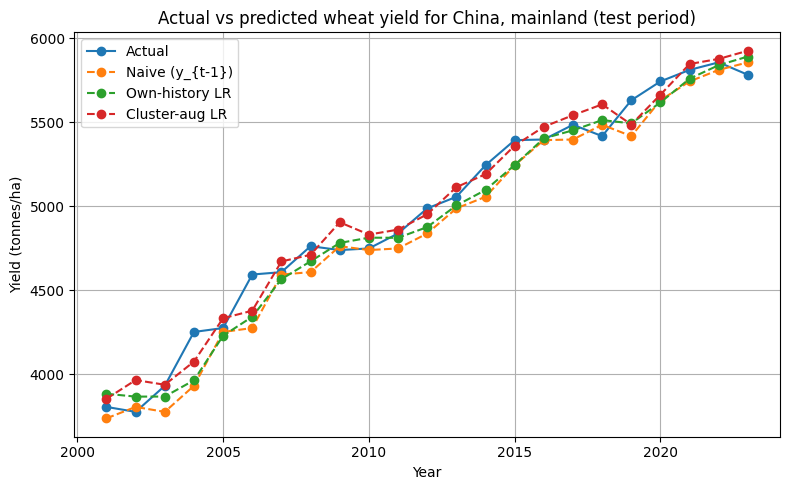

In [396]:
test_years = X_test["Year"]

plt.figure(figsize=(8,5))
plt.plot(test_years, y_test.values, marker="o", label="Actual")
plt.plot(test_years, y_pred_naive.values, marker="o", linestyle="--", label="Naive (y_{t-1})")
plt.plot(test_years, y_pred_own, marker="o", linestyle="--", label="Own-history LR")
plt.plot(test_years, y_pred_cluster, marker="o", linestyle="--", label="Cluster-aug LR")

plt.title(f"Actual vs predicted wheat yield for {target_country} (test period)")
plt.xlabel("Year")
plt.ylabel("Yield (tonnes/ha)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 6. Discussion and limitations

**Summary of findings**

- Global wheat yields have generally increased since 1961, with especially strong growth in [regions].  
- We identified several clusters of countries with distinct yield dynamics (e.g. high-stable vs low-improving vs volatile).  
- Simple models using both own history and cluster information can match or slightly improve on naive baselines in forecasting yields.

**Limitations**

- We use relatively simple interpolation for missing data and a linear trend model; more advanced time-series models might capture nonlinear dynamics better.  
- Clustering results depend on the chosen features and number of clusters (k).  
- We don’t explicitly control for weather, prices, or policy variables that might explain yield patterns.

**Future work**

- Explore more sophisticated clustering (e.g. dynamic time warping, hierarchical clustering).  
- Incorporate weather covariates or input use (fertiliser, irrigation) where available.  
- Add in import/export data to see how it affects yield.
- Use something to map networks and energy transfer.